# Projeto de Business Intelligence: Mercados Financeiros
**Objetivo:** Analisar o comportamento das 20 maiores empresas do S&P 500 em relação ao Ouro, utilizando modelos de Clustering e Associação.

In [13]:
# Manipulação de Dados e Extração
import pandas as pd
import yfinance as yf
import pandas as pd

# Machine Learning (Clustering)
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# Machine Learning (Associação)
from mlxtend.frequent_patterns import apriori, association_rules

# Visualização de Dados (Gráficos)
import matplotlib.pyplot as plt
import seaborn as sns

# Configuração visual para os gráficos ficarem bonitos no VS Code
sns.set_theme(style="whitegrid")
print("Bibliotecas importadas com sucesso!")

Bibliotecas importadas com sucesso!


Extração de Dados e Feature Engineering

In [14]:
# Definir os ativos: As 20 maiores do S&P 500 + Ouro (Ticker: GC=F)
tickers = [
    "AAPL", "MSFT", "AMZN", "NVDA", "GOOGL", "META", "BRK-B", "TSLA", 
    "UNH", "JNJ", "JPM", "V", "PG", "MA", "HD", "CVX", "MRK", "ABBV", 
    "PEP", "KO", "GC=F"
]

# Dicionário para converter os Tickers em Nomes Reais (para gráficos e tabelas)
dicionario_nomes = {
    "AAPL": "Apple", "MSFT": "Microsoft", "AMZN": "Amazon", "NVDA": "Nvidia", 
    "GOOGL": "Google", "META": "Meta", "BRK-B": "Berkshire Hathaway", "TSLA": "Tesla", 
    "UNH": "UnitedHealth", "JNJ": "Johnson & Johnson", "JPM": "JPMorgan", "V": "Visa", 
    "PG": "Procter & Gamble", "MA": "Mastercard", "HD": "Home Depot", "CVX": "Chevron", 
    "MRK": "Merck", "ABBV": "AbbVie", "PEP": "PepsiCo", "KO": "Coca-Cola", "GC=F": "Ouro"
}

print("A extrair dados da internet...")

# Puxar os dados dos últimos 3 anos
dados_brutos = yf.download(tickers, period="3y", interval="1d")

# Ficar apenas com a coluna de Preços de Fecho (Close) e remover valores nulos
precos = dados_brutos['Close'].dropna()

# Feature Engineering: Calcular o Retorno Diário (Variação Percentual)
# Isto é o que os nossos modelos vão usar para aprender
retornos = precos.pct_change().dropna()

# Guardar os dados localmente para não termos de ir à internet sempre que fizermos debug
retornos.to_csv('retornos_financeiros_3anos.csv')

print("Extração concluída com sucesso e guardada no ficheiro CSV!")

# Mostrar as primeiras 5 linhas para confirmar que está tudo ok
display(retornos.head())

[                       0%                       ]

A extrair dados da internet...


[*********************100%***********************]  21 of 21 completed

Extração concluída com sucesso e guardada no ficheiro CSV!


Ticker,AAPL,ABBV,AMZN,BRK-B,CVX,GC=F,GOOGL,HD,JNJ,JPM,...,MA,META,MRK,MSFT,NVDA,PEP,PG,TSLA,UNH,V
Date,,,,,,,,,,,,,,,,,,,,,
2023-05-16,0.000000,-0.022512,0.019784,0.000680,-0.023473,-0.014668,0.025749,-0.021522,-0.001316,-0.006729,...,-0.008268,-0.000168,-0.002492,0.007367,0.008980,-0.004324,-0.001731,0.001022,-0.014665,-0.010051
2023-05-17,0.003603,0.000419,0.018519,0.011243,0.014332,-0.003872,0.011129,0.035632,-0.002196,0.030747,...,0.017778,0.015367,-0.011371,0.009452,0.033033,-0.007083,-0.004238,0.044079,0.010610,0.009459
2023-05-18,0.013666,0.000628,0.022944,0.007239,-0.001233,-0.012218,0.016468,0.009474,-0.003208,0.007584,...,0.012971,0.017980,-0.006623,0.014395,0.049705,-0.002603,-0.016443,0.017428,-0.011510,0.004083
2023-05-19,0.000628,0.011642,-0.016081,0.001910,0.007922,0.011347,-0.000570,-0.014501,0.002713,-0.002294,...,-0.016453,-0.004902,0.013070,-0.000565,-0.013069,0.001462,0.004196,0.018373,-0.000856,-0.001241
2023-05-22,-0.005481,-0.001447,-0.010667,-0.003814,-0.017974,-0.001971,0.018654,-0.000757,-0.005389,-0.008262,...,-0.002697,0.010910,-0.008659,0.008921,-0.002815,-0.027106,-0.026180,0.048462,0.003759,-0.008701


## Modelo de Clusters (K-Means)
**Descobrir o número ideal de grupos com o Método do Cotovelo.**
Nesta fase, os dados são transpostos para focar nas entidades (ações + ouro) é testado de 1 a 10 clusters para encontrar o ponto de equilíbrio matemático (Inércia).

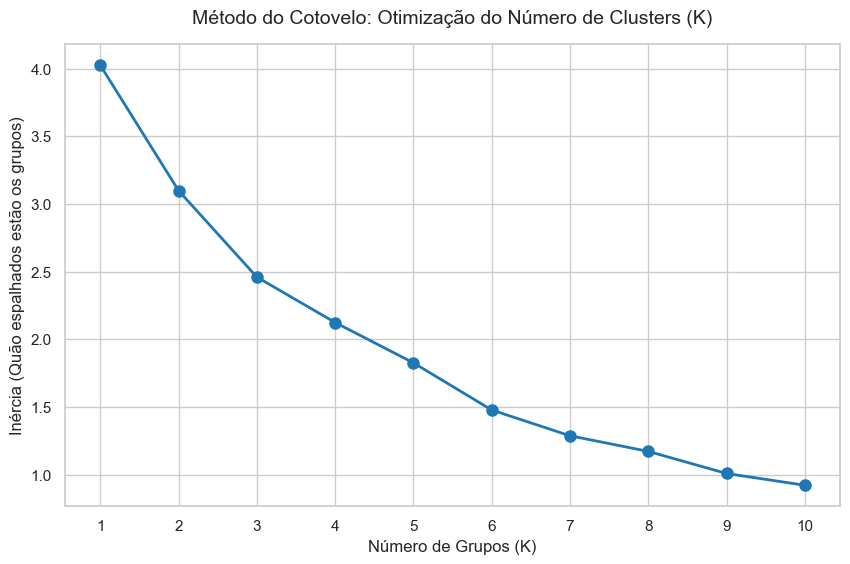

In [15]:
# Virar a tabela: As empresas passam a ser as linhas e os dias as colunas
dados_empresas = retornos.T

# Criar uma lista vazia para guardar a "Inércia" de cada teste
inercia = []
k_valores = range(1, 11) # Testar de 1 a 10 grupos

# Correr o K-Means 10 vezes (uma para cada K)
for k in k_valores:
    # O random_state=42 garante que o resultado se repete
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(dados_empresas)
    inercia.append(kmeans.inertia_) # Guardar a distância matemática

# Desenhar o gráfico
plt.figure(figsize=(10, 6))
plt.plot(k_valores, inercia, marker='o', linestyle='-', color='#1f77b4', linewidth=2, markersize=8)
plt.title('Método do Cotovelo: Otimização do Número de Clusters (K)', fontsize=14, pad=15)
plt.xlabel('Número de Grupos (K)', fontsize=12)
plt.ylabel('Inércia (Quão espalhados estão os grupos)', fontsize=12)
plt.xticks(k_valores)
plt.show()

**Treinar o Modelo K-Means e Analisar os Grupos**
Com base no Método do Cotovelo, K=4 (ou 3). Vai-sse agrupar as empresas e observar a constituição de cada "cluster".

In [16]:
# Definir o número de grupos escolhido (Pode-se mudar o n_clusters para 3)
numero_grupos = 4
kmeans_final = KMeans(n_clusters=numero_grupos, random_state=42, n_init=10)

# Treinar o modelo e atribuir um grupo (label) a cada empresa
dados_empresas['Grupo'] = kmeans_final.fit_predict(dados_empresas)

# Mostrar os resultados
print(f"--- ANÁLISE DOS {numero_grupos} CLUSTERS COMPORTAMENTAIS ---\n")

for i in range(numero_grupos):
    # Pegar nos tickers (ex: 'AAPL')
    tickers_membros = dados_empresas[dados_empresas['Grupo'] == i].index.tolist()
    
    # Traduzir para nomes reais usando o nosso dicionário global
    nomes_reais = [dicionario_nomes.get(t, t) for t in tickers_membros]
    
    print(f"Cluster {i}:")
    print(f"Quantidade: {len(nomes_reais)} ativos")
    print(f"Membros: {', '.join(nomes_reais)}\n")

--- ANÁLISE DOS 4 CLUSTERS COMPORTAMENTAIS ---

Cluster 0:
Quantidade: 15 ativos
Membros: Apple, AbbVie, Berkshire Hathaway, Chevron, Ouro, Home Depot, Johnson & Johnson, JPMorgan, Coca-Cola, Mastercard, Merck, Microsoft, PepsiCo, Procter & Gamble, Visa

Cluster 1:
Quantidade: 1 ativos
Membros: Tesla

Cluster 2:
Quantidade: 1 ativos
Membros: UnitedHealth

Cluster 3:
Quantidade: 4 ativos
Membros: Amazon, Google, Meta, Nvidia



Avaliação do Modelo:

In [17]:
# Separar as features originais da coluna 'Grupo' que acabámos de criar
features_para_avaliar = dados_empresas.drop(columns=['Grupo'])
labels_dos_grupos = dados_empresas['Grupo']

# Calcular o Coeficiente de Silhueta Global
score_silhueta = silhouette_score(features_para_avaliar, labels_dos_grupos)

print("--- AVALIAÇÃO MATEMÁTICA DOS CLUSTERS ---")
print(f"Coeficiente de Silhueta Global (K={numero_grupos}): {score_silhueta:.3f}\n")

# Pequena ajuda para a interpretação
print("Como interpretar este resultado no teu relatório:")
if score_silhueta > 0.5:
    print("-> Estrutura Forte: Os grupos estão muito bem separados e são altamente distintos.")
elif score_silhueta > 0.2:
    print("-> Estrutura Razoável: Existe alguma sobreposição entre os grupos, o que é perfeitamente normal devido à alta correlação do mercado financeiro global.")
elif score_silhueta > 0:
    print("-> Estrutura Fraca: As fronteiras entre os grupos são muito difusas. O mercado comportou-se como um bloco único na maior parte deste período.")
else:
    print("-> Erro de Estrutura: Os dados estão mal classificados.")

--- AVALIAÇÃO MATEMÁTICA DOS CLUSTERS ---
Coeficiente de Silhueta Global (K=4): 0.236

Como interpretar este resultado no teu relatório:
-> Estrutura Razoável: Existe alguma sobreposição entre os grupos, o que é perfeitamente normal devido à alta correlação do mercado financeiro global.


Visualização Espacial (PCA - 2D)

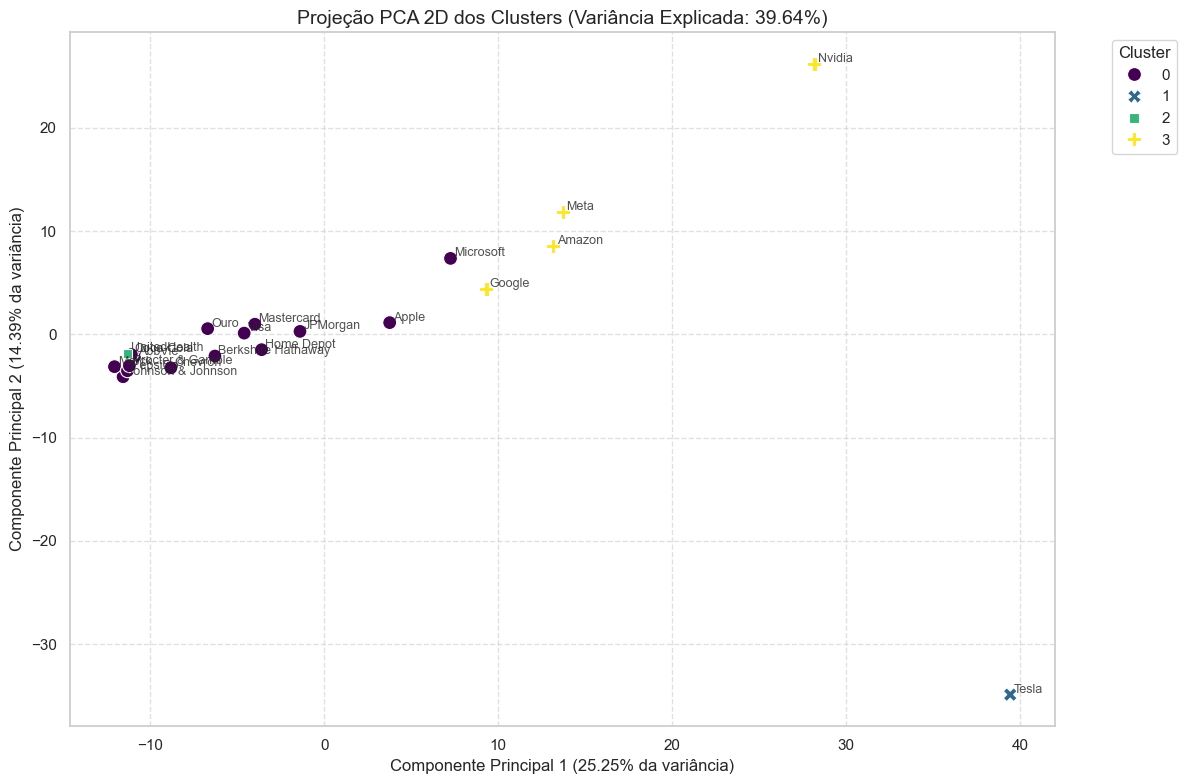

In [18]:
# Normalizar os dados (Obrigatório para PCA)
features = dados_empresas.drop(columns=['Grupo'])
scaler = StandardScaler()
dados_normalizados = scaler.fit_transform(features)

# Aplicar o PCA para 2 componentes
pca = PCA(n_components=2)
componentes_principais = pca.fit_transform(dados_normalizados)

# Criar DataFrame para o gráfico
df_pca = pd.DataFrame(data=componentes_principais, columns=['PC1', 'PC2'])
df_pca['Grupo'] = dados_empresas['Grupo'].values
df_pca['Ticker'] = dados_empresas.index
df_pca['Nome'] = df_pca['Ticker'].map(dicionario_nomes)

# Visualização Profissional
plt.figure(figsize=(12, 8))
scatter = sns.scatterplot(
    data=df_pca, x='PC1', y='PC2', hue='Grupo', 
    palette='viridis', s=100, style='Grupo', markers=True
)

# Adicionar legendas (Nomes das empresas) em cada ponto
for i in range(df_pca.shape[0]):
    plt.text(
        x=df_pca.PC1[i] + 0.2, y=df_pca.PC2[i] + 0.2, 
        s=df_pca.Nome[i], fontsize=9, alpha=0.8
    )

plt.title(f'Projeção PCA 2D dos Clusters (Variância Explicada: {pca.explained_variance_ratio_.sum():.2%})', fontsize=14)
plt.xlabel(f'Componente Principal 1 ({pca.explained_variance_ratio_[0]:.2%} da variância)')
plt.ylabel(f'Componente Principal 2 ({pca.explained_variance_ratio_[1]:.2%} da variância)')
plt.legend(title='Cluster', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

## Modelo de Associação de Dados (Apriori)
**Preparação de Dados e Extração de Regras**
Vai-se transformar os retornos contínuos em eventos categóricos (Subiu/Desceu) para identificar que ações costumam cair ou subir no mesmo dia, revelando o "efeito dominó" do mercado.

In [19]:
# Preparar os dados (Transformar % em Verdadeiro/Falso)
df_subiu = (retornos > 0).add_suffix('_Subiu')
df_desceu = (retornos < 0).add_suffix('_Desceu')

# Juntamos tudo numa única grande tabela binária
dados_apriori = pd.concat([df_subiu, df_desceu], axis=1)

# Correr o Algoritmo Apriori (Mínimo de 15% dos dias)
frequent_itemsets = apriori(dados_apriori, min_support=0.15, use_colnames=True)

# Extrair as Regras de Associação com base no Lift (> 1.5 significa correlação forte)
regras = association_rules(frequent_itemsets, metric="lift", min_threshold=1.5)

# Função GLOBAL de Limpeza (usa o dicionario_nomes do Bloco 1)
def limpar_formatacao_regra(conjunto):
    itens_formatados = []
    for item in conjunto:
        ticker, movimento = item.split('_')
        nome_real = dicionario_nomes.get(ticker, ticker) 
        itens_formatados.append(f"{nome_real} ({movimento})")
    return " + ".join(itens_formatados)

# Preparar Tabela Geral (Ordenada por Confiança)
regras_gerais = regras.sort_values(by='confidence', ascending=False).copy()

regras_gerais['Gatilho (Causa)'] = regras_gerais['antecedents'].apply(limpar_formatacao_regra)
regras_gerais['Efeito (Consequência)'] = regras_gerais['consequents'].apply(limpar_formatacao_regra)

tabela_geral = regras_gerais[['Gatilho (Causa)', 'Efeito (Consequência)', 'support', 'confidence', 'lift']].copy()
tabela_geral.columns = ['Gatilho (Causa)', 'Efeito (Consequência)', 'Suporte', 'Confiança', 'Lift']

# Mostrar Resultados (Sem cortar texto)
pd.set_option('display.max_colwidth', None)
print("--- AS 10 REGRAS GERAIS MAIS FORTES DO MERCADO ---")
display(tabela_geral.round(3).head(10))
pd.reset_option('display.max_colwidth')

--- AS 10 REGRAS GERAIS MAIS FORTES DO MERCADO ---


,Gatilho (Causa),Efeito (Consequência),Suporte,Confiança,Lift
12494,Visa (Subiu) + Amazon (Subiu) + Home Depot (Subiu) + Apple (Subiu),Mastercard (Subiu),0.158,0.952,1.731
21958,Berkshire Hathaway (Subiu) + JPMorgan (Subiu) + Meta (Subiu) + Microsoft (Subiu) + Mastercard (Subiu),Visa (Subiu),0.150,0.950,1.710
18827,Berkshire Hathaway (Subiu) + JPMorgan (Subiu) + Microsoft (Subiu) + Mastercard (Subiu),Visa (Subiu),0.190,0.947,1.706
13020,Visa (Subiu) + Google (Subiu) + Home Depot (Subiu) + Apple (Subiu),Mastercard (Subiu),0.164,0.946,1.720
19280,Berkshire Hathaway (Subiu) + Merck (Subiu) + PepsiCo (Subiu) + Visa (Subiu),Mastercard (Subiu),0.154,0.943,1.715
12946,Berkshire Hathaway (Subiu) + Merck (Subiu) + Apple (Subiu) + Visa (Subiu),Mastercard (Subiu),0.154,0.943,1.715
19232,Berkshire Hathaway (Subiu) + Meta (Subiu) + Microsoft (Subiu) + Mastercard (Subiu),Visa (Subiu),0.173,0.942,1.697
15634,Visa (Subiu) + Google (Subiu) + Amazon (Subiu) + Home Depot (Subiu),Mastercard (Subiu),0.172,0.942,1.712
18002,Berkshire Hathaway (Subiu) + Home Depot (Subiu) + Microsoft (Subiu) + Mastercard (Subiu),Visa (Subiu),0.170,0.941,1.695
13370,Visa (Subiu) + Home Depot (Subiu) + Apple (Subiu) + Microsoft (Subiu),Mastercard (Subiu),0.166,0.940,1.709


**Análise Direcionada (O Comportamento do Ouro)**
Filtro para isolar apenas as regras de mercado que envolvem o ativo de refúgio (GC=F), seja como causa (antecedente) ou como efeito (consequente).

In [20]:
# Criar uma função para procurar a palavra 'GC=F' dentro dos conjuntos (frozensets)
def contem_ouro(conjunto):
    return any('GC=F' in item for item in conjunto)

# Aplicar o filtro: Quer-se regras onde o Ouro seja a causa (antecedents) OU o efeito (consequents)
regras_ouro = regras[
    regras['antecedents'].apply(contem_ouro) | 
    regras['consequents'].apply(contem_ouro)
]

# Ordenar pelo Lift (A correlação mais forte)
regras_ouro = regras_ouro.sort_values(by='lift', ascending=False)

# 2.3. Aplicar a mesma função de limpeza visual
regras_ouro['Gatilho (Causa)'] = regras_ouro['antecedents'].apply(limpar_formatacao_regra)
regras_ouro['Efeito (Consequência)'] = regras_ouro['consequents'].apply(limpar_formatacao_regra)

# 2.4. Preparar Tabela do Ouro
tabela_ouro = regras_ouro[['Gatilho (Causa)', 'Efeito (Consequência)', 'support', 'confidence', 'lift']].copy()
tabela_ouro.columns = ['Gatilho (Causa)', 'Efeito (Consequência)', 'Suporte', 'Confiança', 'Lift']

# 2.5. Mostrar Resultados (Sem cortar texto)
pd.set_option('display.max_colwidth', None)
print("--- AS 10 REGRAS MAIS FORTES ENVOLVENDO O OURO ---")
display(tabela_ouro.round(3).head(10))
pd.reset_option('display.max_colwidth')

--- AS 10 REGRAS MAIS FORTES ENVOLVENDO O OURO ---


,Gatilho (Causa),Efeito (Consequência),Suporte,Confiança,Lift
17141,JPMorgan (Subiu) + Visa (Subiu),Berkshire Hathaway (Subiu) + Mastercard (Subiu) + Ouro (Subiu),0.156,0.413,1.978
17134,Berkshire Hathaway (Subiu) + Mastercard (Subiu) + Ouro (Subiu),JPMorgan (Subiu) + Visa (Subiu),0.156,0.745,1.978
17142,JPMorgan (Subiu) + Mastercard (Subiu),Berkshire Hathaway (Subiu) + Ouro (Subiu) + Visa (Subiu),0.156,0.421,1.975
17133,Berkshire Hathaway (Subiu) + Ouro (Subiu) + Visa (Subiu),JPMorgan (Subiu) + Mastercard (Subiu),0.156,0.731,1.975
17138,Berkshire Hathaway (Subiu) + Visa (Subiu),JPMorgan (Subiu) + Mastercard (Subiu) + Ouro (Subiu),0.156,0.412,1.922
17137,JPMorgan (Subiu) + Mastercard (Subiu) + Ouro (Subiu),Berkshire Hathaway (Subiu) + Visa (Subiu),0.156,0.727,1.922
167,Ouro (Subiu) + Visa (Desceu),Mastercard (Desceu),0.208,0.834,1.854
168,Mastercard (Desceu),Ouro (Subiu) + Visa (Desceu),0.208,0.462,1.854
17135,JPMorgan (Subiu) + Ouro (Subiu) + Visa (Subiu),Berkshire Hathaway (Subiu) + Mastercard (Subiu),0.156,0.701,1.833
17140,Berkshire Hathaway (Subiu) + Mastercard (Subiu),JPMorgan (Subiu) + Ouro (Subiu) + Visa (Subiu),0.156,0.408,1.833
